In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

import statsmodels.api as sm

sns.set_style("whitegrid")


In [4]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully!\n")

# Display first 5 rows
print("First 5 rows:")
print(df.head())


Dataset loaded successfully!

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [5]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Dataset Shape:
(891, 15)

Column Names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object 

In [6]:
df["age"] = df["age"].fillna(df["age"].median())

# Fill missing embarked values with mode
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [7]:
numeric_columns = [
    "age",
    "fare",
    "sibsp",
    "parch"
]

# Mean, median, mode, variance and standard deviation

for col in numeric_columns:

    print("\nVariable:", col)

    print("Mean:",
          df[col].mean())

    print("Median:",
          df[col].median())

    print("Mode:",
          df[col].mode()[0])

    print("Variance:",
          df[col].var())

    print("Standard Deviation:",
          df[col].std())


# Summary statistics
print("\nSummary Statistics:")
print(df[numeric_columns].describe())



Variable: age
Mean: 29.36158249158249
Median: 28.0
Mode: 28.0
Variance: 169.51249827942328
Standard Deviation: 13.019696550973194

Variable: fare
Mean: 32.204207968574636
Median: 14.4542
Mode: 8.05
Variance: 2469.436845743117
Standard Deviation: 49.693428597180905

Variable: sibsp
Mean: 0.5230078563411896
Median: 0.0
Mode: 0
Variance: 1.2160430774662894
Standard Deviation: 1.1027434322934275

Variable: parch
Mean: 0.38159371492704824
Median: 0.0
Mode: 0
Variance: 0.6497282437357467
Standard Deviation: 0.8060572211299559

Summary Statistics:
              age        fare       sibsp       parch
count  891.000000  891.000000  891.000000  891.000000
mean    29.361582   32.204208    0.523008    0.381594
std     13.019697   49.693429    1.102743    0.806057
min      0.420000    0.000000    0.000000    0.000000
25%     22.000000    7.910400    0.000000    0.000000
50%     28.000000   14.454200    0.000000    0.000000
75%     35.000000   31.000000    1.000000    0.000000
max     80.000000  5

Pearson Correlation between Age and Fare: 0.09668842218036486
P-value: 0.0038667538638709515

Correlation Matrix:
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.338481 -0.064910 -0.035322  0.081629  0.257307
pclass   -0.338481  1.000000 -0.339898  0.083081  0.018443 -0.549500
age      -0.064910 -0.339898  1.000000 -0.233296 -0.172482  0.096688
sibsp    -0.035322  0.083081 -0.233296  1.000000  0.414838  0.159651
parch     0.081629  0.018443 -0.172482  0.414838  1.000000  0.216225
fare      0.257307 -0.549500  0.096688  0.159651  0.216225  1.000000


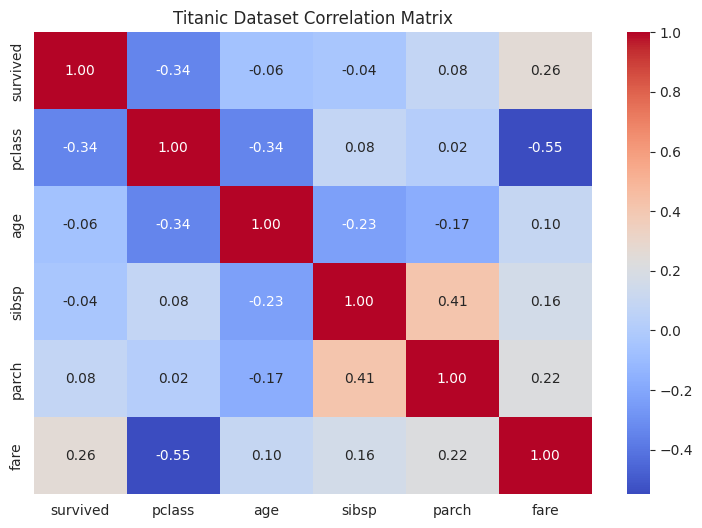

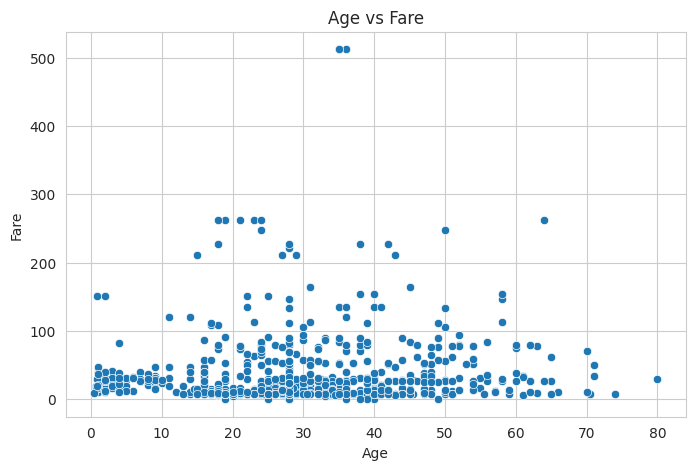

In [8]:

correlation, p_value = pearsonr(
    df["age"],
    df["fare"]
)

print("Pearson Correlation between Age and Fare:",
      correlation)

print("P-value:",
      p_value)


# Correlation Matrix

correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

print("\nCorrelation Matrix:")
print(corr_matrix)


# Heatmap

plt.figure(figsize=(9, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Titanic Dataset Correlation Matrix")
plt.show()


# Scatter Plot

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="age",
    y="fare",
    data=df
)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

In [9]:
print("""
Business Problem:

Is there a significant difference in the average age
of passengers who survived and passengers who did not survive?

Null Hypothesis (H0):
There is no significant difference in mean age between
survived and non-survived passengers.

Alternative Hypothesis (H1):
There is a significant difference in mean age between
survived and non-survived passengers.

Significance Level = 0.05
""")


Business Problem:

Is there a significant difference in the average age
of passengers who survived and passengers who did not survive?

Null Hypothesis (H0):
There is no significant difference in mean age between
survived and non-survived passengers.

Alternative Hypothesis (H1):
There is a significant difference in mean age between
survived and non-survived passengers.

Significance Level = 0.05



Mean Age of Survivors: 28.29143274853801
Mean Age of Non-Survivors: 30.028233151183972

T-statistic: -1.8966053920256696
P-value: 0.058309159977757444

Decision: Fail to Reject H0
Conclusion: There is no statistically significant difference in the mean age of survivors and non-survivors.


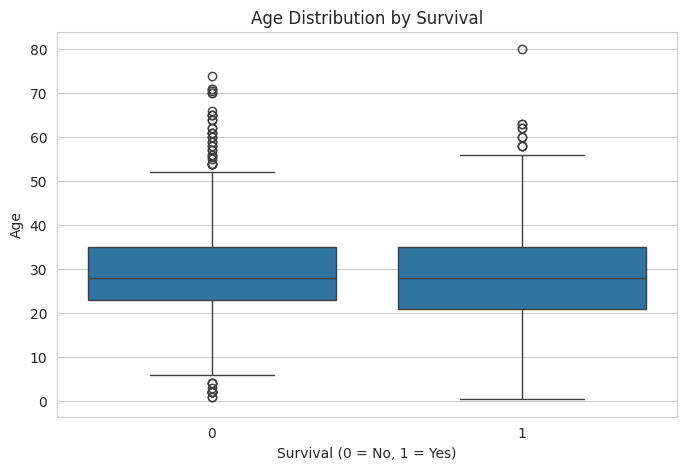

In [10]:
age_survived = df[
    df["survived"] == 1
]["age"]

# Age of passengers who did not survive
age_not_survived = df[
    df["survived"] == 0
]["age"]


print("Mean Age of Survivors:",
      age_survived.mean())

print("Mean Age of Non-Survivors:",
      age_not_survived.mean())


# Perform independent sample t-test

t_stat, t_pvalue = ttest_ind(
    age_survived,
    age_not_survived,
    equal_var=False
)

print("\nT-statistic:",
      t_stat)

print("P-value:",
      t_pvalue)


# Decision

alpha = 0.05

if t_pvalue < alpha:

    print("\nDecision: Reject H0")

    print(
        "Conclusion: There is a statistically significant "
        "difference in the mean age of survivors and "
        "non-survivors."
    )

else:

    print("\nDecision: Fail to Reject H0")

    print(
        "Conclusion: There is no statistically significant "
        "difference in the mean age of survivors and "
        "non-survivors."
    )


# Boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="survived",
    y="age",
    data=df
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survival (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()


Business Problem:

Is there a significant difference in the average fare
paid by passengers belonging to different passenger classes?

H0:
The mean fare is the same for all passenger classes.

H1:
At least one passenger class has a significantly
different mean fare.

Mean Fare - Class 1: 84.1546875
Mean Fare - Class 2: 20.662183152173913
Mean Fare - Class 3: 13.675550101832993

F-statistic: 242.34415651744814
P-value: 1.0313763209141171e-84

Decision: Reject H0
Conclusion: There is a statistically significant difference in average fare among passenger classes.


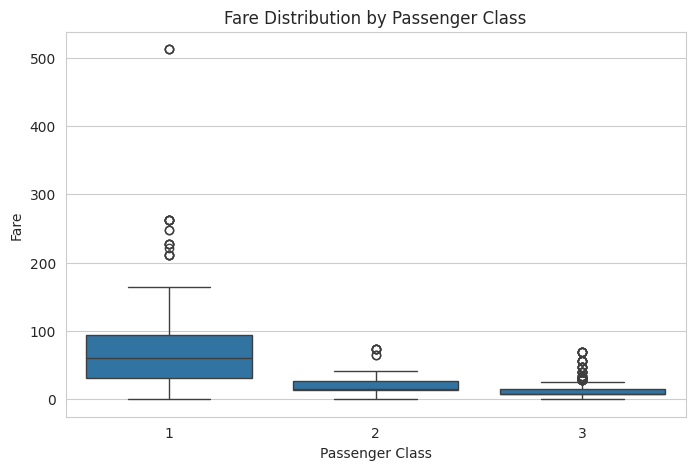

In [11]:
print("""
Business Problem:

Is there a significant difference in the average fare
paid by passengers belonging to different passenger classes?

H0:
The mean fare is the same for all passenger classes.

H1:
At least one passenger class has a significantly
different mean fare.
""")


# Create groups for each passenger class

fare_class1 = df[
    df["pclass"] == 1
]["fare"]

fare_class2 = df[
    df["pclass"] == 2
]["fare"]

fare_class3 = df[
    df["pclass"] == 3
]["fare"]


print("Mean Fare - Class 1:",
      fare_class1.mean())

print("Mean Fare - Class 2:",
      fare_class2.mean())

print("Mean Fare - Class 3:",
      fare_class3.mean())


# Perform ANOVA

f_stat, anova_pvalue = f_oneway(
    fare_class1,
    fare_class2,
    fare_class3
)

print("\nF-statistic:",
      f_stat)

print("P-value:",
      anova_pvalue)


# Decision

if anova_pvalue < alpha:

    print("\nDecision: Reject H0")

    print(
        "Conclusion: There is a statistically significant "
        "difference in average fare among passenger classes."
    )

else:

    print("\nDecision: Fail to Reject H0")

    print(
        "Conclusion: There is no statistically significant "
        "difference in average fare among passenger classes."
    )


# Boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="pclass",
    y="fare",
    data=df
)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.show()


In [14]:
print("""
Regression Model:

Fare = β0 + β1(Age) + ε

Independent Variable:
Age

Dependent Variable:
Fare
""")


# Independent variable
X = df["age"]

# Dependent variable
y = df["fare"]


# Add constant/intercept
X = sm.add_constant(X)


# Create regression model
model = sm.OLS(y, X).fit()


# Display regression results
print(model.summary())



Regression Model:

Fare = β0 + β1(Age) + ε

Independent Variable:
Age

Dependent Variable:
Fare

                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     8.389
Date:                Mon, 05 Oct 2026   Prob (F-statistic):            0.00387
Time:                        16:35:53   Log-Likelihood:                -4739.7
No. Observations:                 891   AIC:                             9483.
Df Residuals:                     889   BIC:                             9493.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------


Regression Coefficients:
const    21.368631
age       0.369039
dtype: float64

P-values:
const    2.203317e-07
age      3.866754e-03
dtype: float64

R-squared:
0.00934865098372839

Adjusted R-squared:
0.008234307509019434

95% Confidence Intervals:
               0          1
const  13.337695  29.399568
age     0.118977   0.619101

Age Coefficient: 0.36903926178178786
Age P-value: 0.0038667538638709584

Age has a statistically significant linear relationship with Fare.


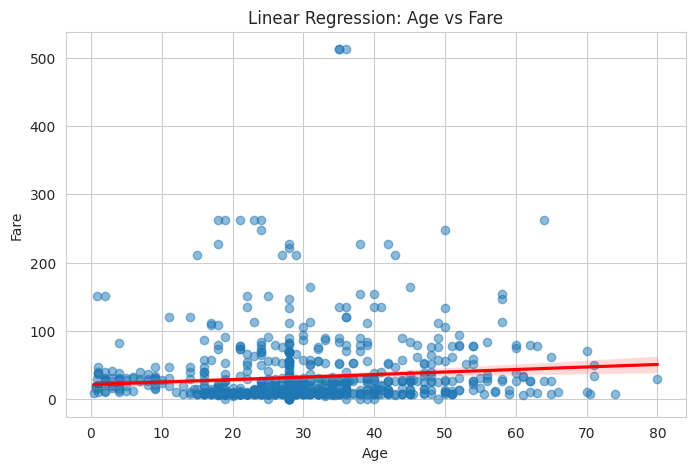

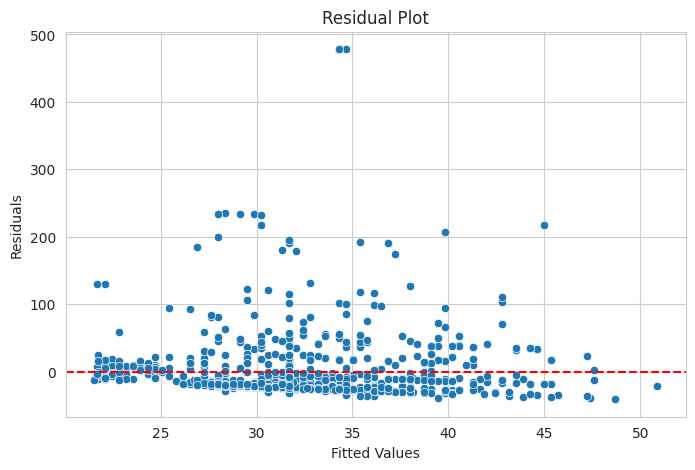

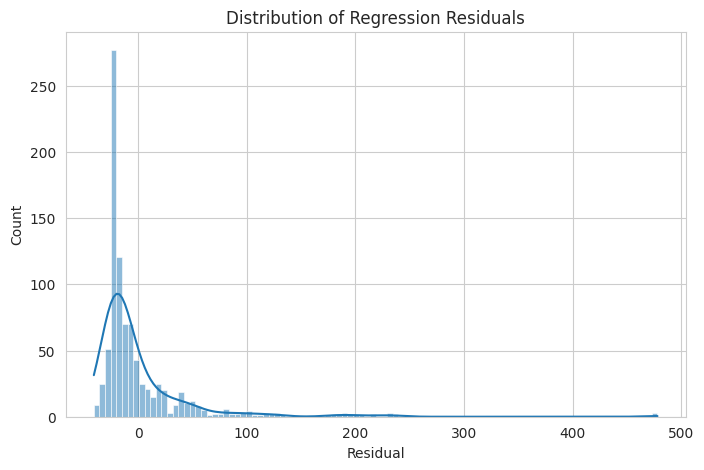

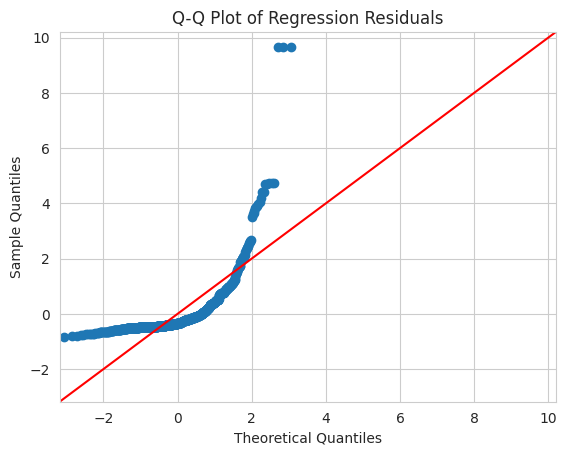

In [15]:
print("\nRegression Coefficients:")
print(model.params)


# P-values

print("\nP-values:")
print(model.pvalues)


# R-squared

print("\nR-squared:")
print(model.rsquared)


# Adjusted R-squared

print("\nAdjusted R-squared:")
print(model.rsquared_adj)


# 95% Confidence Intervals

print("\n95% Confidence Intervals:")
print(model.conf_int(alpha=0.05))


# Interpretation of Age coefficient

age_coefficient = model.params["age"]

age_pvalue = model.pvalues["age"]

print("\nAge Coefficient:",
      age_coefficient)

print("Age P-value:",
      age_pvalue)


if age_pvalue < alpha:

    print(
        "\nAge has a statistically significant "
        "linear relationship with Fare."
    )

else:

    print(
        "\nAge does not have a statistically significant "
        "linear relationship with Fare."
    )

plt.figure(figsize=(8, 5))

sns.regplot(
    x="age",
    y="fare",
    data=df,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)

plt.title("Linear Regression: Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()


residuals = model.resid

fitted_values = model.fittedvalues


# Residual plot

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=fitted_values,
    y=residuals
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")

plt.show()

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Regression Residuals")

plt.show()



In [16]:
print("""
1. Descriptive statistics were calculated for Age, Fare,
   SibSp and Parch.

2. Pearson correlation was used to measure the linear
   relationship between Age and Fare.

3. An independent sample t-test was performed to compare
   the mean age of survivors and non-survivors.

4. One-way ANOVA was performed to determine whether
   passenger class had a significant effect on Fare.

5. Simple linear regression was performed to examine
   the relationship between Age and Fare.

6. P-values, regression coefficients, R-squared,
   adjusted R-squared and 95% confidence intervals
   were calculated.

7. Residual plots and Q-Q plots were used to examine
   regression assumptions.

8. The results can help understand factors associated
   with passenger survival and ticket pricing.
""")


1. Descriptive statistics were calculated for Age, Fare,
   SibSp and Parch.

2. Pearson correlation was used to measure the linear
   relationship between Age and Fare.

3. An independent sample t-test was performed to compare
   the mean age of survivors and non-survivors.

4. One-way ANOVA was performed to determine whether
   passenger class had a significant effect on Fare.

5. Simple linear regression was performed to examine
   the relationship between Age and Fare.

6. P-values, regression coefficients, R-squared,
   adjusted R-squared and 95% confidence intervals
   were calculated.

7. Residual plots and Q-Q plots were used to examine
   regression assumptions.

8. The results can help understand factors associated
   with passenger survival and ticket pricing.

